In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("C:\\Users\\HP\\Downloads\\matplotlib_messy_sales_2000 - matplotlib_messy_sales_2000.csv")
df.head(10)

,Customer ID,Order Date,City,Product Category,Customer Segment,Gender,Sales Channel,Age,Units Sold,Unit Price,Discount %,Customer Rating,Is Active,Returned,Payment Method,Gross Sales,Discount Amount,Revenue,Cost,Profit
0,CUST00594,2025-05-05 0:00:00,Mumbai,Clothing,premium,Male,Retail,36,8,24235.73,22.91,1.9,1,0,UPI,193885.84,44419.25,149466.59,88698.45,60768.14
1,CUST01103,2025-10-22 0:00:00,Mumbai,Clothing,Premium,Female,Corporate,38,5,16789.55,10.59,4.3,1,0,Cash,83947.75,8890.07,75057.68,61426.31,13631.37
2,CUST00690,2025-04-24 0:00:00,Delhi,Home & Kitchen,Regular,Male,Retail,65,2,24579.97,36.22,4.5,1,0,Debit Card,49159.94,17805.73,31354.21,24948.21,6406.00
3,CUST00215,2025-05-17 0:00:00,Chennai,Electronics,Regular,Male,Corporate,34,9,6240.13,20.44,3.9,1,0,Net Banking,56161.17,11479.34,NaN,26470.33,18211.50
4,CUST01270,2025-08-30 0:00:00,Delhi,Clothing,Budget,Female,Corporate,41,1,23491.23,10.48,3.7,1,0,Net Banking,23491.23,2461.88,21029.35,12312.38,8716.97
5,CUST00848,2025-06-03 0:00:00,Hyderabad,Electronics,Regular,Male,Corporate,49,8,1808.3,38.1,2.1,1,0,UPI,14466.40,5511.70,8954.70,5812.34,3142.36
6,CUST00150,2025-07-26 0:00:00,Delhi,Home & Kitchen,Premium,Male,Online,29,10,28497.86,11.54,2.1,1,1,Debit Card,284978.60,32886.53,252092.07,157266.39,94825.68
7,CUST01115,2025-03-10 0:00:00,Pune,home & kitchen,Budget,Female,Corporate,46,12,23023.33,9.16,3.5,1,0,Debit Card,276279.96,25307.24,250972.72,182977.99,67994.73
8,CUST00927,2025-03-22 0:00:00,Mumbai,Clothing,Regular,Female,Retail,61,12,250000,35.94,1.6,1,1,Net Banking,213087.24,76583.55,136503.69,92634.53,43869.16
9,CUST00686,2025-05-14 0:00:00,Bengaluru,Electronics,Regular,Male,Online,25,1,18649.79,7.74,1.9,1,0,Credit Card,18649.79,1443.49,17206.30,13130.58,4075.72


#### 1. Monthly Revenue Line Chart
#### Using order_date and revenue:
#### • Convert order_date to datetime.
#### • Calculate total revenue for each month.
#### • Create a line chart.
#### • Add:
#### o Title
#### o X-axis label
#### o Y-axis label
#### o Grid
#### o Markers
#### 
#### Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

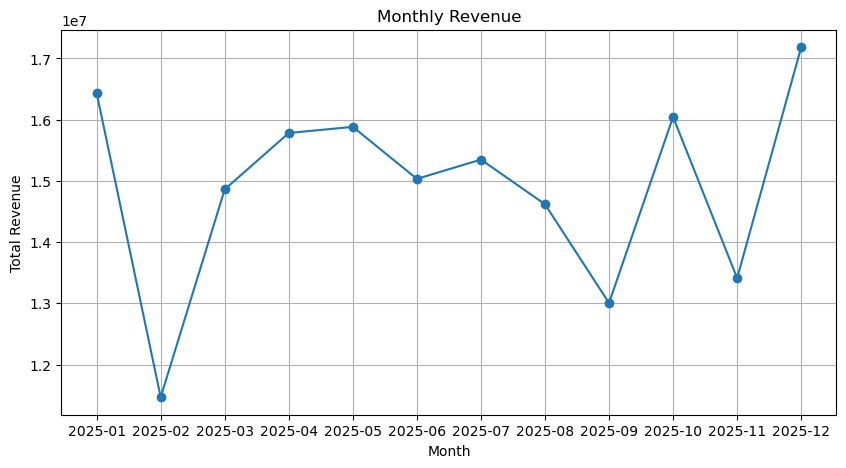

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)
df = df.dropna(subset=["Order Date"])
monthly_revenue = df.groupby(df["Order Date"].dt.to_period("M"))["Revenue"].sum()
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

#### 2. Monthly Profit Line Chart
#### Create a line chart showing monthly Profit.
#### Requirements:
#### • Use a different line style.
#### • Add markers.
#### • Add a legend.
#### • Display the value of the highest-profit month using annotate().
#### Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["Order Date"])

# Calculate total profit for each month
monthly_Profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()

print(monthly_Profit)

Order Date
2025-01    5256690.78
2025-02    3516340.41
2025-03    4638856.93
2025-04    5219010.06
2025-05    5211112.10
2025-06    4864554.54
2025-07    4749443.78
2025-08    4883550.53
2025-09    4525419.15
2025-10    5249550.39
2025-11    4475543.42
2025-12    5678426.89
Freq: M, Name: Profit, dtype: float64


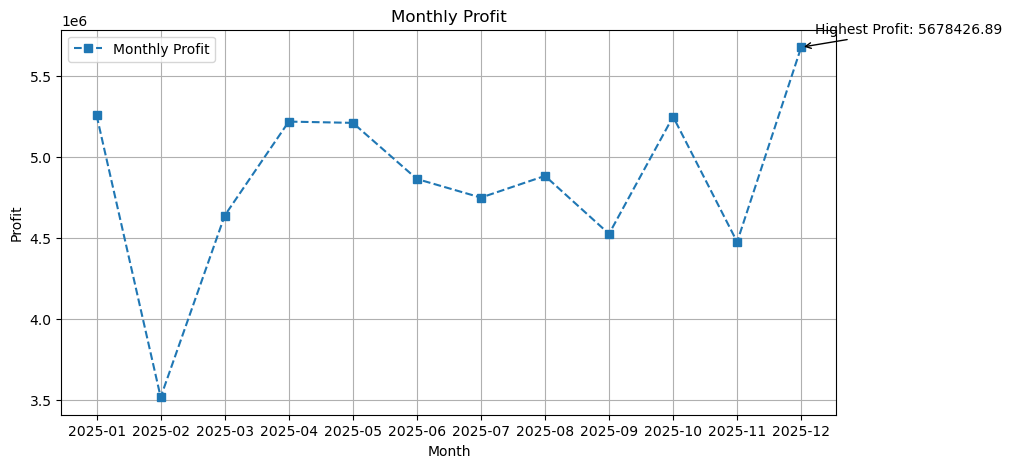

In [5]:
# Find highest profit
max_profit = monthly_Profit.max()
max_month = monthly_Profit.idxmax()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_Profit.index.astype(str),
    monthly_Profit.values,
    linestyle="--",
    marker="s",
    linewidth=1.5,
    label="Monthly Profit"
)

# Add legend
plt.legend()

# Annotate highest profit
plt.annotate(
    f"Highest Profit: {max_profit:.2f}",
    xy=(str(max_month), max_profit),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

#### 3. Revenue by Product Category — Bar Chart
#### Calculate total revenue for each product_category.
#### Create a bar chart.
#### Requirements:
#### • X-axis → Product Category
#### 
#### Sumit Sir Notes
#### • Y-axis → Revenue
#### • Add title and labels.
#### • Display the revenue value above each bar.
#### Commands/concepts: plt.bar(), plt.text()

### 1. Column Names
### Display all column names. Identify columns having leading/trailing spaces and
### rename all columns into a consistent snake_case format.

In [6]:
df.columns

Index(['Customer ID', 'Order Date', 'City', 'Product Category',
       'Customer Segment', 'Gender', 'Sales Channel', 'Age', 'Units Sold',
       'Unit Price', 'Discount %', 'Customer Rating', 'Is Active', 'Returned',
       'Payment Method', 'Gross Sales', 'Discount Amount', 'Revenue', 'Cost',
       'Profit'],
      dtype='object')

In [7]:
for col in df.columns:
    if col != col.strip():
        print("Column with spaces:", repr(col))
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
)

print(df.columns)

Index(['customer_id', 'order_date', 'city', 'product_category',
       'customer_segment', 'gender', 'sales_channel', 'age', 'units_sold',
       'unit_price', 'discount_percent', 'customer_rating', 'is_active',
       'returned', 'payment_method', 'gross_sales', 'discount_amount',
       'revenue', 'cost', 'profit'],
      dtype='object')


#### 2. Duplicate Records
#### Find the number of duplicate rows. Remove the duplicate records and verify that no
#### duplicates remain.

In [8]:
df.duplicated().sum()

np.int64(20)

In [9]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
df = df.drop_duplicates()
print("Duplicates remaining:", df.duplicated().sum())

Number of duplicate rows: 20
Duplicates remaining: 0


#### 3. Missing Values
#### Display the missing-value count and missing-value percentage for every column.

In [10]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_summary)

                  Missing Count  Missing Percentage
customer_id                   0                0.00
order_date                    0                0.00
city                         25                1.27
product_category             24                1.22
customer_segment              0                0.00
gender                        0                0.00
sales_channel                 0                0.00
age                          27                1.37
units_sold                    4                0.20
unit_price                   24                1.22
discount_percent             28                1.42
customer_rating              24                1.22
is_active                     0                0.00
returned                      0                0.00
payment_method               25                1.27
gross_sales                   0                0.00
discount_amount               0                0.00
revenue                      25                1.27
cost        

#### 4. Missing Categorical Values
#### Handle missing values in city, product_category, and payment_method using an
#### appropriate strategy.

In [11]:
df["city"].fillna(df["city"].mode()[0])
df["product_category"].fillna(df["product_category"].mode()[0])
df["payment_method"].fillna(df["payment_method"].mode()[0])

0               UPI
1              Cash
2        Debit Card
3       Net Banking
4       Net Banking
           ...     
2015            UPI
2016           Cash
2017            UPI
2018            UPI
2019    Credit Card
Name: payment_method, Length: 1975, dtype: object

#### 5. Missing Numerical Values
#### Handle missing values in age, unit_price, discount_pct, customer_rating, and
#### revenue. Explain why you selected mean, median, or another method.

In [14]:
pd.to_numeric(df["age"], errors="coerce")
pd.to_numeric(df["unit_price"], errors="coerce")
pd.to_numeric(df["discount_pct"], errors="coerce")
pd.to_numeric(df["customer_rating"], errors="coerce")
pd.to_numeric(df["revenue"], errors="coerce")

KeyError: 'discount_pct'

#### 6. Date Cleaning
#### Convert order_date into a proper datetime format. Identify invalid date values and
#### handle them appropriately.

In [15]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

# Count invalid dates
invalid_dates = df["order_date"].isna().sum()

print("Invalid dates:", invalid_dates)

# Display invalid-date rows
print(df[df["order_date"].isna()])

# Remove invalid dates
df = df.dropna(subset=["order_date"])

# Verify
print("Invalid dates remaining:",
      df["order_date"].isna().sum())

Invalid dates: 0
Empty DataFrame
Columns: [customer_id, order_date, city, product_category, customer_segment, gender, sales_channel, age, units_sold, unit_price, discount_percent, customer_rating, is_active, returned, payment_method, gross_sales, discount_amount, revenue, cost, profit]
Index: []
Invalid dates remaining: 0


#### 7. Age Cleaning
#### The age column contains values such as 25 years, 30 yrs, 45Y, and N/A. Extract the
#### numerical age and convert the column into a numeric datatype.